# Microscope Design Curves

This notebook assembles the complete set of **design curves** (lens focal lengths and drive currents) for a model TEM column, covering three operating modes:

| Mode | Control variable | Source |
|------|-----------------|--------|
| **A — Condenser spot size** | Spot index (1–8) | Solved here (CL1, CL3) |
| **B — IL magnification** | System magnification (30k–600k×) | Loaded from `microscope.toml` |
| **C — Diffraction camera length** | Camera length | Loaded from `microscope.toml` |

### Data flow

- Column geometry (z-positions, turns, Gc) is read from `microscope.toml`.
- IL imaging and diffraction mode curves are read from `microscope.toml` mode tables.
- This notebook recomputes condenser curves and can write updated mode tables back to `microscope.toml`.
- Obj_post and PL1 currents are fixed by the objective and projector focal lengths.

### Output

The notebook updates mode-table design curves directly in `microscope.toml`.

## 1 — Imports and Microscope Configuration

All physical dimensions and lens parameters are loaded from `microscope.toml`. Solver targets are defined inline below. Distances are in **metres**, voltages in **volts**.

In [3]:
import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.01"

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import brentq, least_squares

from temgym_core.transfer_matrices import propagation_matrix, lens_matrix
from temgym_core.constants import compute_Rc_from_voltage
from temgym_core.microscope_model import MicroscopeModel, OperatingMode, LensConfig

try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib  # type: ignore[no-redef]

%matplotlib widget

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True

# ══════════════════════════════════════════════════════════════
# Load column geometry from microscope.toml
# ══════════════════════════════════════════════════════════════

toml_path = Path("microscope.toml")
with open(toml_path, "rb") as f:
    toml_cfg = tomllib.load(f)

# ── Beam ──
beam_cfg = toml_cfg['beam']

# ── Lens z-positions, turns, Gc ──
lens_table = toml_cfg['lenses']
z = {name: float(spec['z_m']) for name, spec in lens_table.items()}
turns_all = {name: float(spec['turns']) for name, spec in lens_table.items()}
Gc_all = {name: float(spec['Gc']) for name, spec in lens_table.items() if 'Gc' in spec}

# ── Aperture ──
z_aperture = float(toml_cfg['apertures']['C_aperture']['z_m'])

# ── Distances derived from toml z-positions ──
geometry = {
    'd_Source_to_CL1':          z['CL1'],
    'd_CL1_to_CL3':            z['CL3'] - z['CL1'],
    'd_CL3_to_Aperture':       z_aperture - z['CL3'],
    'd_Aperture_to_Cmini':     z['C_mini'] - z_aperture,
    'd_Cmini_to_ObjPrefield':  z['Obj_prefield'] - z['C_mini'],
    'd_ObjPrefield_to_Sample':  5.0e-3,
    'd_Sample_to_ObjPost':      2.3e-3,
    'd_ObjPost_to_IL1':         z['IL1'] - z['Obj_post'],
    'd_IL1_to_IL2':             z['IL2'] - z['IL1'],
    'd_IL2_to_IL3':             z['IL3'] - z['IL2'],
    'd_IL3_to_PL1':             z['PL1'] - z['IL3'],
    'd_PL1_to_detector':        0.325,
}

# Sanity: Obj_prefield + 5 mm + 2.3 mm should equal Obj_post z
_z_obj_post_check = z['Obj_prefield'] + geometry['d_ObjPrefield_to_Sample'] + geometry['d_Sample_to_ObjPost']
assert abs(_z_obj_post_check - z['Obj_post']) < 1e-6, (
    f"Obj_post z mismatch: derived {_z_obj_post_check:.6f} vs toml {z['Obj_post']:.6f}"
)

# ── Fixed focal lengths (not parameterised by Gc in the solver) ──
optics = {
    'f_Cmini_m':       5.0e-3,
    'f_ObjPrefield_m': 5.0e-3,
}

# ── Condenser solver targets ──
solver_targets = {
    'condenser_spots': {
        'N_spots': 8,
        'target_sample_min_nm': 500.0,
        'target_sample_max_nm': 5000.0,
        'I_A_bounds':      {'CL1': (0.4, 1.9), 'CL3': (0.4, 1.9)},
        'f_solver_bounds':  {'CL1': (0.8e-3, 120.0e-3), 'CL3': (0.8e-3, 900.0e-3)},
        'f_tens_bounds':    {'CL1': (5.0e-3, 30.0e-3), 'CL3': (5.0e-3, 30.0e-3)},
        'scan_points': 2500,
    },
}

# ══════════════════════════════════════════════════════════════
# Derived quantities
# ══════════════════════════════════════════════════════════════

U_accel_V = beam_cfg['voltage_kV'] * 1000.0
Rc_phys = float(compute_Rc_from_voltage(U_accel_V))

# --- Condenser geometry ---
geometry_cond = {
    'd_S_C1':      geometry['d_Source_to_CL1'],
    'd_C1_C3':     geometry['d_CL1_to_CL3'],
    'd_C3_A':      geometry['d_CL3_to_Aperture'],
    'd_A_Cmini':   geometry['d_Aperture_to_Cmini'],
    'd_Cmini_OPL': geometry['d_Cmini_to_ObjPrefield'],
    'f_Cmini':     optics['f_Cmini_m'],
    'f_OPL':       optics['f_ObjPrefield_m'],
}

turns_cond    = {k: turns_all[k] for k in ['CL1', 'CL3']}
Gc_phys_cond  = {k: Gc_all[k]   for k in ['CL1', 'CL3']}
I_A_bounds_cond = solver_targets['condenser_spots']['I_A_bounds']
AT_bounds_cond  = {k: (turns_cond[k] * lo, turns_cond[k] * hi) for k, (lo, hi) in I_A_bounds_cond.items()}

N_spots                      = solver_targets['condenser_spots']['N_spots']
f3_scan_points               = solver_targets['condenser_spots']['scan_points']
sample_rel_tolerance         = 2e-2
conjugate_eps                = 1e-6
requested_sample_target_min_nm = solver_targets['condenser_spots']['target_sample_min_nm']
requested_sample_target_max_nm = solver_targets['condenser_spots']['target_sample_max_nm']
f_solver_bounds_cond         = solver_targets['condenser_spots']['f_solver_bounds']
enforce_tens_mm_cond         = True
f_tens_bounds_cond           = solver_targets['condenser_spots']['f_tens_bounds']

virtual_source_diameter_nm   = beam_cfg['virtual_source_diameter_nm']
source_half_angle_mrad       = beam_cfg['source_half_angle_mrad']
sample_distance_from_opl_m   = geometry_cond['f_OPL']
source_sigma_x_m             = 0.5 * virtual_source_diameter_nm * 1e-9
source_sigma_theta_rad       = source_half_angle_mrad * 1e-3

# --- Objective and projector parameters ---
M_obj  = -30.0
M_proj = -100.0

# --- Objective imaging ---
u_obj_m            = geometry['d_Sample_to_ObjPost']
v_obj_m            = abs(M_obj) * u_obj_m
f_obj_required_m   = u_obj_m * v_obj_m / (u_obj_m + v_obj_m)
d_ObjPost_to_IL1   = geometry['d_ObjPost_to_IL1']
d_obj_image_to_il1 = d_ObjPost_to_IL1 - v_obj_m

if d_obj_image_to_il1 <= 0:
    raise ValueError(
        f'Objective image at v={v_obj_m*1e3:.1f} mm past Obj_post exceeds '
        f'd_ObjPost_to_IL1={d_ObjPost_to_IL1*1e3:.1f} mm.'
    )

# --- Projector geometry ---
d_pre_PL1_image_to_PL1 = geometry['d_PL1_to_detector'] / abs(M_proj)

geometry_proj = {
    'd_il3_to_pl1':            geometry['d_IL3_to_PL1'],
    'd_pre_pl1_image_to_pl1':  d_pre_PL1_image_to_PL1,
    'd_pl1_to_detector':       geometry['d_PL1_to_detector'],
}

# --- IL geometry ---
geometry_mag = {
    'd_obj_image_to_il1': d_obj_image_to_il1,
    'd_il1_to_il2':       geometry['d_IL1_to_IL2'],
    'd_il2_to_il3':       geometry['d_IL2_to_IL3'],
    'd_il3_to_image':     geometry_proj['d_il3_to_pl1'] - geometry_proj['d_pre_pl1_image_to_pl1'],
}

# --- Diffraction geometry (BFP relay, metadata only) ---
d_bfp_to_il1 = float(d_ObjPost_to_IL1 - f_obj_required_m)
if d_bfp_to_il1 <= 0:
    raise ValueError('Invalid diffraction geometry: BFP must be upstream of IL1.')

geometry_diff = {
    'd_bfp_to_il1':   d_bfp_to_il1,
    'd_il1_to_il2':   geometry['d_IL1_to_IL2'],
    'd_il2_to_il3':   geometry['d_IL2_to_IL3'],
    'd_il3_to_image': geometry_mag['d_il3_to_image'],
}

f_pl1_target_m = 1.0 / (1.0 / geometry_proj['d_pre_pl1_image_to_pl1'] + 1.0 / geometry_proj['d_pl1_to_detector'])

# --- Rotation cancellation target (Obj_post + PL1 fixed currents) ---
Gc_objpost_cfg = Gc_all['Obj_post']
Gc_pl1_cfg     = Gc_all['PL1']
ni_objpost_mag = float(np.sqrt(1.0 / (Gc_objpost_cfg * f_obj_required_m)))
ni_pl1_mag     = float(np.sqrt(1.0 / (Gc_pl1_cfg * f_pl1_target_m)))
theta_target   = float(Rc_phys * (ni_objpost_mag + ni_pl1_mag))

# --- Summary ---
print(f'Column geometry loaded from {toml_path}')
print(f'Rc = {Rc_phys:.4e} rad/AT')
print(f'Objective: M_obj = {M_obj},  u = {u_obj_m*1e3:.3f} mm,  v = {v_obj_m*1e3:.3f} mm,  '
      f'f = {f_obj_required_m*1e3:.4f} mm,  NI = {ni_objpost_mag:.1f} AT')
print(f'd_obj_image → IL1 = {d_obj_image_to_il1*1e3:.3f} mm  '
      f'(d_ObjPost → IL1 = {d_ObjPost_to_IL1*1e3:.3f} mm)')
print(f'BFP → IL1: {d_bfp_to_il1*1e3:.3f} mm')
print(f'IL gaps [mm]:  IL1↔IL2 = {geometry_mag["d_il1_to_il2"]*1e3:.3f},  '
      f'IL2↔IL3 = {geometry_mag["d_il2_to_il3"]*1e3:.3f},  '
      f'IL3↔image = {geometry_mag["d_il3_to_image"]*1e3:.3f}')
print(f'PL1: f = {f_pl1_target_m*1e3:.4f} mm,  d_IL3↔PL1 = {geometry_proj["d_il3_to_pl1"]*1e3:.3f} mm')
print(f'Rotation target (Obj_post + PL1): theta = {np.rad2deg(theta_target):.2f}°')

Column geometry loaded from microscope.toml
Rc = 5.3015e-04 rad/AT
Objective: M_obj = -30.0,  u = 2.300 mm,  v = 69.000 mm,  f = 2.2258 mm,  NI = 7494.0 AT
d_obj_image → IL1 = 31.000 mm  (d_ObjPost → IL1 = 100.000 mm)
BFP → IL1: 97.774 mm
IL gaps [mm]:  IL1↔IL2 = 61.233,  IL2↔IL3 = 68.851,  IL3↔image = 44.199
PL1: f = 3.2178 mm,  d_IL3↔PL1 = 47.449 mm
Rotation target (Obj_post + PL1): theta = 416.95°


## 2 — Transfer-Matrix Primitives and Shared Helpers

These utility functions are used by both the condenser and IL solvers:
- `build_chain` / `extract_abcd` — compose 3×3 transfer matrices and extract the 2×2 ABCD elements.
- `currents_from_focal_lengths` — convert focal lengths to coil currents via $1/f = G_c \cdot NI^2$.
- `scalar_root_solve` — bracket-and-Brentq root finder for design-curve residuals.
- `focal_bounds_from_current_bounds` — invert current limits into focal-length limits.

In [4]:
# ── Transfer-matrix composition ──

def build_chain(elements, xp=np):
    """Compose a sequence of propagation ('P', d) and lens ('L', f) elements."""
    M = xp.eye(3)
    for kind, value in elements:
        if kind == 'P':
            op = propagation_matrix(value, xp=xp)
        elif kind == 'L':
            op = lens_matrix(value, xp=xp)
        else:
            raise ValueError(f'Unknown element kind: {kind}')
        M = op @ M
    return M


def extract_abcd(M):
    """Extract (A, B, C, D) from a 3×3 transfer matrix."""
    return M[0, 0], M[0, 1], M[1, 0], M[1, 1]


# ── Focal length ↔ current conversion ──

def currents_from_focal_lengths(f_map, gc_phys_map, turns_map):
    """Convert {lens_name: focal_length} to {I_A_name, AT_name} using 1/f = Gc·NI²."""
    out = {}
    for k, f in f_map.items():
        if (not np.isfinite(f)) or (f <= 0.0):
            return None
        at = float(np.sqrt(1.0 / (gc_phys_map[k] * f)))
        out[f'I_A_{k}'] = float(at / turns_map[k])
        out[f'AT_{k}'] = at
    return out


def apply_hard_bounds_and_flag(row, i_a_bounds, at_bounds):
    """Return True if all currents in `row` are within bounds."""
    for k, (lo, hi) in i_a_bounds.items():
        if not (lo <= row[f'I_A_{k}'] <= hi):
            return False
    for k, (lo, hi) in at_bounds.items():
        if not (lo <= row[f'AT_{k}'] <= hi):
            return False
    return True


# ── Root-finding helpers ──

def choose_bracket(f_grid, r_grid, prev_root=None):
    """Find a sign-change bracket in (f_grid, r_grid), preferring one near prev_root."""
    finite = np.isfinite(r_grid)
    if not np.any(finite):
        return None

    g = f_grid[finite]
    r = r_grid[finite]

    candidates = []
    for a, b, ra, rb in zip(g[:-1], g[1:], r[:-1], r[1:]):
        if ra == 0.0:
            candidates.append((float(a), float(a)))
        elif ra * rb < 0.0:
            candidates.append((float(a), float(b)))

    if len(candidates) == 0:
        return None
    if prev_root is None:
        return candidates[0]

    mids = np.array([0.5 * (a + b) for (a, b) in candidates], dtype=float)
    j = int(np.argmin(np.abs(mids - prev_root)))
    return candidates[j]


def scalar_root_solve(residual_fn, f_grid, prev_root=None, maxiter=200):
    """Bracket-and-Brentq root finder.  Falls back to nearest-to-zero if no bracket."""
    r_grid = np.array([residual_fn(float(x)) for x in f_grid], dtype=float)
    bracket = choose_bracket(f_grid, r_grid, prev_root=prev_root)

    converged = False
    if bracket is None:
        finite = np.isfinite(r_grid)
        if not np.any(finite):
            raise RuntimeError('No finite residuals in scalar_root_solve')
        g = f_grid[finite]
        r = r_grid[finite]
        root = float(g[np.argmin(np.abs(r))])
    elif bracket[0] == bracket[1]:
        root = float(bracket[0])
        converged = True
    else:
        root = float(brentq(lambda x: residual_fn(float(x)), bracket[0], bracket[1], maxiter=maxiter))
        converged = True

    return root, converged


# ── Focal-length bounds from current limits ──

def focal_bounds_from_current_bounds(gc_phys, turns, i_min, i_max):
    """Invert I_min/I_max into (f_min, f_max) via 1/f = Gc·(N·I)²."""
    return 1.0 / (gc_phys * (turns * i_max)**2), 1.0 / (gc_phys * (turns * i_min)**2)


f_phys_bounds = {
    k: focal_bounds_from_current_bounds(Gc_phys_cond[k], turns_cond[k], *I_A_bounds_cond[k])
    for k in turns_cond
}
f_bounds_cond = {
    k: (
        max(f_solver_bounds_cond[k][0], f_phys_bounds[k][0]),
        min(f_solver_bounds_cond[k][1], f_phys_bounds[k][1]),
    )
    for k in turns_cond
}
if enforce_tens_mm_cond:
    f_bounds_cond = {
        k: (
            max(f_bounds_cond[k][0], f_tens_bounds_cond[k][0]),
            min(f_bounds_cond[k][1], f_tens_bounds_cond[k][1]),
        )
        for k in turns_cond
    }
    for k, (lo, hi) in f_bounds_cond.items():
        if lo >= hi:
            raise ValueError(f'No feasible focal range for {k}: bounds={f_bounds_cond[k]}')

print(f'Condenser focal bounds [mm]: { {k: tuple(round(1e3*x, 2) for x in v) for k, v in f_bounds_cond.items()} }')

Condenser focal bounds [mm]: {'CL1': (5.0, 30.0), 'CL3': (5.34, 30.0)}


## 3 — Mode A: Condenser Spot-Size Design Curves

The condenser system images the virtual source onto the sample through CL1 → CL3 → C_mini → Obj_prefield.  C_mini and Obj_prefield are at fixed focal lengths; only CL1 and CL3 vary.

**Approach:**
1. Compute the C_mini conjugate geometry (fixed imaging through C_mini + Obj_prefield).
2. Scan CL3 focal length over the allowed range; for each CL3, numerically solve for CL1 such that B = 0 at the C_mini object plane (real image condition).
3. Propagate the Gaussian source beam through the full condenser chain and compute the FWHM sample spot size.
4. Invert the FWHM(f_CL3) curve at N geometrically-spaced target spot sizes to get N spot-index settings.

In [5]:
# ── C_mini conjugate calculation ──
#
#   C_mini images a point in the CL3→Aperture space to the Obj_prefield
#   focal plane.  d_obj_cmini is the object distance for C_mini;
#   d_img_fopl is the image distance (= d_Cmini_to_ObjPrefield - f_OPL).

def compute_cmini_conjugate_distance(geom, eps):
    d_img_fopl = float(geom['d_Cmini_OPL'] - geom['f_OPL'])
    f_cmini = float(geom['f_Cmini'])
    d_c3_to_cmini = float(geom['d_C3_A'] + geom['d_A_Cmini'])

    if not np.isfinite(d_img_fopl):
        raise ValueError('Invalid d_img_fopl (non-finite).')
    if not (d_img_fopl > f_cmini + eps):
        raise ValueError(
            'Invalid CLmini conjugate geometry: require d_img_fopl > f_Cmini + eps. '
            f'Got d_img_fopl={d_img_fopl:.6e}, f_Cmini={f_cmini:.6e}, eps={eps:.1e}.'
        )

    denom = (1.0 / f_cmini) - (1.0 / d_img_fopl)
    if abs(denom) <= 1e-15:
        raise ValueError('Invalid CLmini conjugate geometry (denominator near zero).')

    d_obj_cmini = 1.0 / denom
    if (not np.isfinite(d_obj_cmini)) or (d_obj_cmini <= 0.0):
        raise ValueError(f'Invalid d_obj_cmini from conjugate calculation: {d_obj_cmini:.6e}.')
    if not (d_obj_cmini < d_c3_to_cmini):
        raise ValueError(
            'Invalid CLmini object-plane location: require d_obj_cmini < d_C3_A + d_A_Cmini.'
        )

    drift_to_ocmini = d_c3_to_cmini - d_obj_cmini
    return float(d_img_fopl), float(d_obj_cmini), float(drift_to_ocmini)


d_img_fopl, d_obj_cmini, drift_to_ocmini = compute_cmini_conjugate_distance(geometry_cond, conjugate_eps)
print(f'CLmini conjugate: d_img_fopl = {d_img_fopl*1e3:.4f} mm, '
      f'd_obj_cmini = {d_obj_cmini*1e3:.4f} mm, drift = {drift_to_ocmini*1e3:.4f} mm')


# ── Condenser transfer matrices ──

def system_matrix_pre(f_cl1, f_cl3, geom, d_obj_cmini_local):
    """Source → C_mini object plane (CL1 + CL3 only)."""
    drift = (geom['d_C3_A'] + geom['d_A_Cmini']) - d_obj_cmini_local
    elems = [
        ('P', geom['d_S_C1']),
        ('L', f_cl1),
        ('P', geom['d_C1_C3']),
        ('L', f_cl3),
        ('P', drift),
    ]
    return build_chain(elems, xp=np)


def system_matrix_cond_to_fopl(f_cl1, f_cl3, geom, d_obj_cmini_local, d_img_fopl_local):
    """Source → Obj_prefield focal plane (CL1 + CL3 + C_mini)."""
    M_pre = system_matrix_pre(f_cl1, f_cl3, geom, d_obj_cmini_local)
    M_cmini = build_chain([
        ('P', d_obj_cmini_local),
        ('L', geom['f_Cmini']),
        ('P', d_img_fopl_local),
    ], xp=np)
    return M_cmini @ M_pre


def system_matrix_fopl_to_sample(geom, z_sample):
    """Obj_prefield focal plane → sample."""
    return build_chain([
        ('P', geom['f_OPL']),
        ('L', geom['f_OPL']),
        ('P', z_sample),
    ], xp=np)


# ── Gaussian beam propagation ──

def q_inv_from_source_model(sigma_x_m, sigma_theta_rad, wavelength_m):
    """Build complex 1/q from source size and divergence."""
    if not (np.isfinite(sigma_x_m) and sigma_x_m > 0.0):
        raise ValueError(f'Invalid sigma_x_m={sigma_x_m}')
    if not (np.isfinite(sigma_theta_rad) and sigma_theta_rad > 0.0):
        raise ValueError(f'Invalid sigma_theta_rad={sigma_theta_rad}')
    if not (np.isfinite(wavelength_m) and wavelength_m > 0.0):
        raise ValueError(f'Invalid wavelength_m={wavelength_m}')

    w = 2.0 * sigma_x_m
    q_inv_im = wavelength_m / (np.pi * w * w)

    sigma_theta_diff = wavelength_m / (2.0 * np.pi * w)
    sigma_theta_curv_sq = max(sigma_theta_rad**2 - sigma_theta_diff**2, 0.0)

    if sigma_theta_curv_sq <= 0.0:
        q_inv_re = 0.0
    else:
        q_inv_re = float(np.sqrt(sigma_theta_curv_sq)) / sigma_x_m

    return complex(q_inv_re, q_inv_im)


def propagate_q_inv_abcd(q_inv_in, M_2x2, tiny=1e-15):
    """ABCD-law propagation: q_out^{-1} = (C + D·q_in^{-1}) / (A + B·q_in^{-1})."""
    A, B = float(M_2x2[0, 0]), float(M_2x2[0, 1])
    C, D = float(M_2x2[1, 0]), float(M_2x2[1, 1])
    denom = A + B * q_inv_in
    if abs(denom) <= tiny:
        return None
    return (C + D * q_inv_in) / denom


def fwhm_from_q_inv(q_inv_out, wavelength_m):
    """Beam FWHM from the imaginary part of 1/q."""
    q_inv_im = float(np.imag(q_inv_out))
    if not (np.isfinite(q_inv_im) and q_inv_im > 0.0):
        return np.inf
    w = np.sqrt(wavelength_m / (np.pi * q_inv_im))
    return float(w * np.sqrt(2.0 * np.log(2.0)))


# ── Staged real-imaging constraint ──

def lens_image_distance(f_lens, s_object, tiny=1e-15):
    denom = (1.0 / f_lens) - (1.0 / s_object)
    if abs(denom) <= tiny:
        return None
    s_image = 1.0 / denom
    return float(s_image) if np.isfinite(s_image) else None


def enforce_staged_real_imaging(f_cl1, f_cl3, geom, d_obj_cmini_local, residual_tol=1e-5, tiny=1e-12):
    """Check that CL1 forms a real image between CL1 and CL3, and CL3 relays it to the C_mini object plane."""
    s1 = float(geom['d_S_C1'])
    d12 = float(geom['d_C1_C3'])
    s3p = float((geom['d_C3_A'] + geom['d_A_Cmini']) - d_obj_cmini_local)

    if min(s1, d12, s3p) <= tiny:
        return None

    s1p = lens_image_distance(f_cl1, s1, tiny=tiny)
    if (s1p is None) or (s1p <= tiny):
        return None
    if not (s1p < d12 - tiny):
        return None

    s3 = float(d12 - s1p)
    if s3 <= tiny:
        return None

    r3 = 1.0/f_cl3 - 1.0/s3 - 1.0/s3p
    scale = max(abs(1.0/f_cl3), abs(1.0/s3) + abs(1.0/s3p), 1.0)
    if abs(r3) > residual_tol * scale:
        return None

    M_joint = build_chain([
        ('P', s1), ('L', f_cl1), ('P', d12), ('L', f_cl3), ('P', s3p),
    ], xp=np)
    _, B_joint, _, _ = extract_abcd(M_joint)

    return {
        's1_obj_m': float(s1), 's1_img_m': float(s1p),
        's3_obj_m': float(s3), 's3_img_m': float(s3p),
        'r3_residual': float(r3), 'B_joint': float(B_joint),
    }


imaging_residual_tol = 1e-5


# ── Source beam and fixed optics ──

lambda_e_m = float(12.264306e-10 / np.sqrt(U_accel_V * (1.0 + 0.978466e-6 * U_accel_V)))
q_inv_source = q_inv_from_source_model(source_sigma_x_m, source_sigma_theta_rad, lambda_e_m)
print(f'Source q⁻¹: Re = {np.real(q_inv_source):.3e}, Im = {np.imag(q_inv_source):.3e} 1/m  '
      f'(λ = {lambda_e_m*1e12:.4f} pm)')

M_fopl_to_sample = system_matrix_fopl_to_sample(geometry_cond, sample_distance_from_opl_m)
A_fs, B_fs, _, _ = extract_abcd(M_fopl_to_sample)
print(f'ObjPrefield → sample: A = {float(A_fs):.3e},  B = {float(B_fs):.3e} m/rad')


# ── Candidate evaluator (one CL3 focal length → full condenser solution) ──

def f1_from_f3_numeric_pre(f3, geom, f1_lo, f1_hi, d_obj_cmini_local, n_scan=500):
    """Given f_CL3, find f_CL1 such that B_pre = 0 (image at C_mini object plane)."""
    f1_grid = np.geomspace(f1_lo, f1_hi, int(n_scan))
    def b_pre_of_f1(x):
        M_pre = system_matrix_pre(x, f3, geom, d_obj_cmini_local)
        _, B_pre, _, _ = extract_abcd(M_pre)
        return float(B_pre)
    root, _ = scalar_root_solve(b_pre_of_f1, f1_grid, prev_root=None, maxiter=200)
    return float(root)


def evaluate_candidate_cond(f3, geom, f_bounds_local, d_obj_cmini_local, d_img_fopl_local):
    """Evaluate one condenser candidate at a given f_CL3.  Returns dict or None."""
    if not np.isfinite(f3) or f3 <= 0:
        return None
    if not (f_bounds_local['CL3'][0] <= f3 <= f_bounds_local['CL3'][1]):
        return None

    f1 = f1_from_f3_numeric_pre(f3, geom, f_bounds_local['CL1'][0], f_bounds_local['CL1'][1], d_obj_cmini_local)
    if not np.isfinite(f1) or f1 <= 0:
        return None
    if not (f_bounds_local['CL1'][0] <= f1 <= f_bounds_local['CL1'][1]):
        return None

    staged = enforce_staged_real_imaging(f1, f3, geom, d_obj_cmini_local, residual_tol=imaging_residual_tol)
    if staged is None:
        return None

    M_pre = system_matrix_pre(f1, f3, geom, d_obj_cmini_local)
    A_pre, B_pre, _, _ = extract_abcd(M_pre)

    M_sfopl = system_matrix_cond_to_fopl(f1, f3, geom, d_obj_cmini_local, d_img_fopl_local)
    A_fopl, B_fopl, _, _ = extract_abcd(M_sfopl)

    M_total = M_fopl_to_sample @ M_sfopl
    M_total_2x2 = np.asarray(M_total[:2, :2], dtype=float)
    q_inv_sample = propagate_q_inv_abcd(q_inv_source, M_total_2x2)
    if q_inv_sample is None:
        return None

    fwhm_sample_nm = float(fwhm_from_q_inv(q_inv_sample, lambda_e_m) * 1e9)
    if not np.isfinite(fwhm_sample_nm):
        return None

    cur = currents_from_focal_lengths({'CL1': f1, 'CL3': f3}, Gc_phys_cond, turns_cond)
    if cur is None:
        return None
    if not apply_hard_bounds_and_flag(cur, I_A_bounds_cond, AT_bounds_cond):
        return None

    out = {
        'f_CL1': float(f1), 'f_CL3': float(f3),
        'A_pre_abs': float(abs(A_pre)), 'A_fopl_abs': float(abs(A_fopl)),
        'B_pre': float(B_pre), 'B_fopl': float(B_fopl),
        'fwhm_sample_nm': fwhm_sample_nm,
        'q_inv_sample_re_1pm': float(np.real(q_inv_sample) * 1e-12),
        'q_inv_sample_im_1pm': float(np.imag(q_inv_sample) * 1e-12),
        'd_obj_cmini': float(d_obj_cmini_local),
        's1_img_mm': float(staged['s1_img_m'] * 1e3),
        's3_obj_mm': float(staged['s3_obj_m'] * 1e3),
        's3_img_mm': float(staged['s3_img_m'] * 1e3),
        'r3_residual': float(staged['r3_residual']),
        'B_joint_residual': float(staged['B_joint']),
    }
    out.update(cur)
    return out


# ── Scan CL3 focal-length range and collect feasible candidates ──

f3_grid = np.geomspace(f_bounds_cond['CL3'][0], f_bounds_cond['CL3'][1], int(f3_scan_points))
feasible = []
for f3 in f3_grid:
    cand = evaluate_candidate_cond(float(f3), geometry_cond, f_bounds_cond, d_obj_cmini, d_img_fopl)
    if cand is not None:
        feasible.append(cand)

if len(feasible) < N_spots:
    raise RuntimeError(
        f'Insufficient feasible candidates ({len(feasible)}) for N_spots={N_spots}. '
        'Relax geometry or electrical bounds.'
    )

feasible_sorted = sorted(feasible, key=lambda r: r['f_CL3'])
f3_scan = np.array([r['f_CL3'] for r in feasible_sorted], dtype=float)
fwhm_sample_scan_nm = np.array([r['fwhm_sample_nm'] for r in feasible_sorted], dtype=float)

candidate_cache = {float(r['f_CL3']): r for r in feasible_sorted}

def get_candidate_cached(f3):
    key = float(f3)
    if key in candidate_cache:
        return candidate_cache[key]
    c = evaluate_candidate_cond(key, geometry_cond, f_bounds_cond, d_obj_cmini, d_img_fopl)
    if c is not None:
        candidate_cache[key] = c
    return c

def fwhm_sample_interp_nm(f3):
    return float(np.interp(float(f3), f3_scan, fwhm_sample_scan_nm))


# ── Choose spot-size targets and solve for each ──

def resolve_sample_targets(feasible_nm, req_min_nm, req_max_nm, n_spots):
    lo = max(float(req_min_nm), float(np.min(feasible_nm)))
    hi = min(float(req_max_nm), float(np.max(feasible_nm)))
    return np.geomspace(lo, hi, int(n_spots)), 'requested_overlap'


sample_targets_nm, sample_target_mode_used = resolve_sample_targets(
    fwhm_sample_scan_nm, requested_sample_target_min_nm, requested_sample_target_max_nm, N_spots)
print(f'Sample FWHM targets [nm]: {np.array2string(sample_targets_nm, precision=0)}')


results_cond = []
prev_root = None

for i, d_t_nm in enumerate(sample_targets_nm, start=1):
    def residual_sample_interp(x):
        return fwhm_sample_interp_nm(x) - d_t_nm

    root_f3, converged = scalar_root_solve(residual_sample_interp, f3_scan, prev_root=prev_root, maxiter=200)
    c = get_candidate_cached(root_f3)
    if c is None:
        raise RuntimeError(f'Invalid physics candidate at spot {i}')

    d_err_abs = float(c['fwhm_sample_nm'] - d_t_nm)
    d_err_rel = float(d_err_abs / d_t_nm)
    converged_final = bool(converged or (abs(d_err_rel) <= sample_rel_tolerance))

    results_cond.append({
        'spot_index': int(i),
        'fwhm_sample_target_nm': float(d_t_nm),
        'fwhm_sample_solved_nm': float(c['fwhm_sample_nm']),
        'fwhm_sample_err_abs_nm': d_err_abs,
        'fwhm_sample_err_rel': d_err_rel,
        'A_pre_abs': float(c['A_pre_abs']),
        'A_fopl_abs': float(c['A_fopl_abs']),
        'B_pre_residual': float(c['B_pre']),
        'B_fopl_residual': float(c['B_fopl']),
        'sample_target_mode': sample_target_mode_used,
        'f_CL1': float(c['f_CL1']),
        'f_CL3': float(c['f_CL3']),
        'I_A_CL1': float(c['I_A_CL1']),
        'I_A_CL3': float(c['I_A_CL3']),
        'AT_CL1': float(c['AT_CL1']),
        'AT_CL3': float(c['AT_CL3']),
        'q_inv_sample_re_1pm': float(c['q_inv_sample_re_1pm']),
        'q_inv_sample_im_1pm': float(c['q_inv_sample_im_1pm']),
        's1_img_mm': float(c['s1_img_mm']),
        's3_obj_mm': float(c['s3_obj_mm']),
        's3_img_mm': float(c['s3_img_mm']),
        'r3_residual': float(c['r3_residual']),
        'B_joint_residual': float(c['B_joint_residual']),
        'converged': converged_final,
    })
    prev_root = root_f3

# Sort by CL1 focal length (descending) and renumber
results_cond = sorted(results_cond, key=lambda r: r['f_CL1'], reverse=True)
for j, row in enumerate(results_cond, start=1):
    row['spot_index'] = int(j)

print(f'Solved {len(results_cond)} condenser spots  '
      f'({sum(int(r["converged"]) for r in results_cond)}/{len(results_cond)} converged)')

CLmini conjugate: d_img_fopl = 15.0000 mm, d_obj_cmini = 7.5000 mm, drift = 52.5000 mm
Source q⁻¹: Re = 6.023e+03, Im = 7.983e+03 1/m  (λ = 2.5079 pm)
ObjPrefield → sample: A = -2.082e-17,  B = 5.000e-03 m/rad
Sample FWHM targets [nm]: [ 500.  695.  965. 1341. 1864. 2590. 3598. 5000.]
Solved 8 condenser spots  (8/8 converged)


## 4 — Mode B: Magnification Design Curves (from microscope.toml)

The IL imaging table is read from `[modes.imaging.magnification]` in `microscope.toml`.
For each row, IL currents are converted to focal lengths via:

$$f_k = \frac{1}{G_{c,k}\,(N_k I_k)^2}$$

with $G_{c,k}$ and $N_k$ taken from the lens table in `microscope.toml`.

In [6]:
# ── Load IL imaging mode table from microscope.toml ───────────────────

mode_mag = toml_cfg['modes']['imaging']['magnification']
mag_headers = list(mode_mag['headers'])
mag_values = list(mode_mag['values'])
mag_idx = {k: i for i, k in enumerate(mag_headers)}

required_cols = ['mag', 'IL1', 'IL2', 'IL3']
missing = [c for c in required_cols if c not in mag_idx]
if missing:
    raise KeyError(f'microscope.toml [modes.imaging.magnification] missing columns: {missing}')

target_system_mags = np.array([float(row[mag_idx['mag']]) for row in mag_values], dtype=float)

mag_results = []
for row in mag_values:
    i1 = float(row[mag_idx['IL1']])
    i2 = float(row[mag_idx['IL2']])
    i3 = float(row[mag_idx['IL3']])

    at1 = float(turns_all['IL1'] * i1)
    at2 = float(turns_all['IL2'] * i2)
    at3 = float(turns_all['IL3'] * i3)

    f1 = float(1.0 / (Gc_all['IL1'] * at1**2)) if at1 != 0 else np.inf
    f2 = float(1.0 / (Gc_all['IL2'] * at2**2)) if at2 != 0 else np.inf
    f3 = float(1.0 / (Gc_all['IL3'] * at3**2)) if at3 != 0 else np.inf

    mag_results.append({
        'M_system': float(row[mag_idx['mag']]),
        'f1_m': f1,
        'f2_m': f2,
        'f3_m': f3,
        'I1_A': i1,
        'I2_A': i2,
        'I3_A': i3,
        'AT1': at1,
        'AT2': at2,
        'AT3': at3,
    })

theta_il_img = Rc_phys * np.array([r['AT1'] + r['AT2'] + r['AT3'] for r in mag_results], dtype=float)

print(f'Loaded {len(mag_results)} imaging mode points from microscope.toml')
print(f'System magnifications: {target_system_mags.astype(int).tolist()}')
print(f'IL rotation [deg]: min = {np.rad2deg(theta_il_img.min()):.2f},  '
      f'max = {np.rad2deg(theta_il_img.max()):.2f}')
print(f'Rotation target (Obj_post + PL1): {np.rad2deg(theta_target):.2f} deg')

Loaded 5 imaging mode points from microscope.toml
System magnifications: [30000, 50000, 100000, 300000, 600000]
IL rotation [deg]: min = 382.73,  max = 382.73
Rotation target (Obj_post + PL1): 416.95 deg


## 5 — Mode C: Diffraction (Camera-Length) Design Curves (from microscope.toml)

The IL diffraction table is read from `[modes.imaging.diffraction]` in `microscope.toml`.
The same current-to-focal conversion is used:

$$f_k = \frac{1}{G_{c,k}\,(N_k I_k)^2}$$

Camera length values are interpreted as metres unless they look like millimetres (max > 5), in which case they are converted to metres.

In [7]:
# ── Load IL diffraction (camera-length) mode table from microscope.toml ──

mode_diff = toml_cfg['modes']['imaging']['diffraction']
diff_headers = list(mode_diff['headers'])
diff_values = list(mode_diff['values'])
diff_idx = {k: i for i, k in enumerate(diff_headers)}

required_cols = ['camera_length', 'IL1', 'IL2', 'IL3']
missing = [c for c in required_cols if c not in diff_idx]
if missing:
    raise KeyError(f'microscope.toml [modes.imaging.diffraction] missing columns: {missing}')

raw_camera_lengths = np.array([float(row[diff_idx['camera_length']]) for row in diff_values], dtype=float)
# Heuristic: legacy tables may store camera length in mm, while design notebook uses m.
if np.nanmax(raw_camera_lengths) > 5.0:
    target_camera_lengths_m = raw_camera_lengths * 1e-3
else:
    target_camera_lengths_m = raw_camera_lengths

diff_results = []
for row, Lc_m in zip(diff_values, target_camera_lengths_m):
    i1 = float(row[diff_idx['IL1']])
    i2 = float(row[diff_idx['IL2']])
    i3 = float(row[diff_idx['IL3']])

    at1 = float(turns_all['IL1'] * i1)
    at2 = float(turns_all['IL2'] * i2)
    at3 = float(turns_all['IL3'] * i3)

    f1 = float(1.0 / (Gc_all['IL1'] * at1**2)) if at1 != 0 else np.inf
    f2 = float(1.0 / (Gc_all['IL2'] * at2**2)) if at2 != 0 else np.inf
    f3 = float(1.0 / (Gc_all['IL3'] * at3**2)) if at3 != 0 else np.inf

    diff_results.append({
        'camera_length_target_m': float(Lc_m),
        'f1_m': f1,
        'f2_m': f2,
        'f3_m': f3,
        'I1_A': i1,
        'I2_A': i2,
        'I3_A': i3,
        'AT1': at1,
        'AT2': at2,
        'AT3': at3,
    })

theta_il_diff = Rc_phys * np.array([r['AT1'] + r['AT2'] + r['AT3'] for r in diff_results], dtype=float)

print(f'Loaded {len(diff_results)} diffraction mode points from microscope.toml')
print(f'Camera lengths [m]: {target_camera_lengths_m.tolist()}')
print(f'IL rotation [deg]: min = {np.rad2deg(theta_il_diff.min()):.2f},  '
      f'max = {np.rad2deg(theta_il_diff.max()):.2f}')
print(f'Rotation target (Obj_post + PL1): {np.rad2deg(theta_target):.2f} deg')

Loaded 5 diffraction mode points from microscope.toml
Camera lengths [m]: [0.01, 0.02, 0.03, 0.04, 0.05]
IL rotation [deg]: min = 382.73,  max = 382.73
Rotation target (Obj_post + PL1): 416.95 deg


## 6 — Plotting, Validation, and TOML Write-Back

This final section does four things:
- plots condenser and imaging-mode magnification curves,
- plots diffraction camera-length curves,
- verifies the fixed ObjPost and PL1 settings that close the full rotation budget,
- writes updated mode tables (`illumination.parallel`, `imaging.magnification`, `imaging.diffraction`) back to `microscope.toml`.

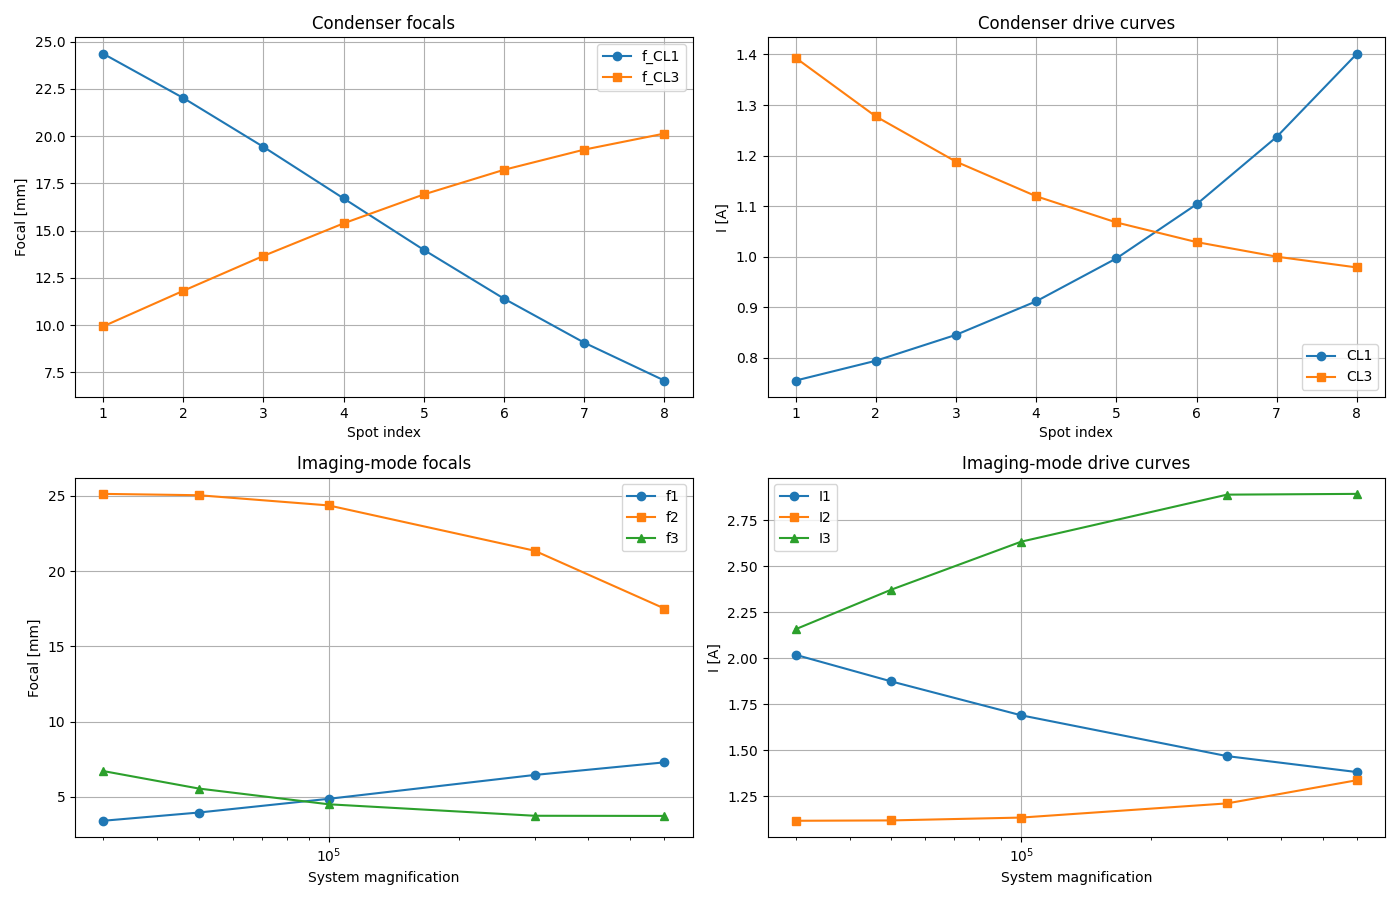

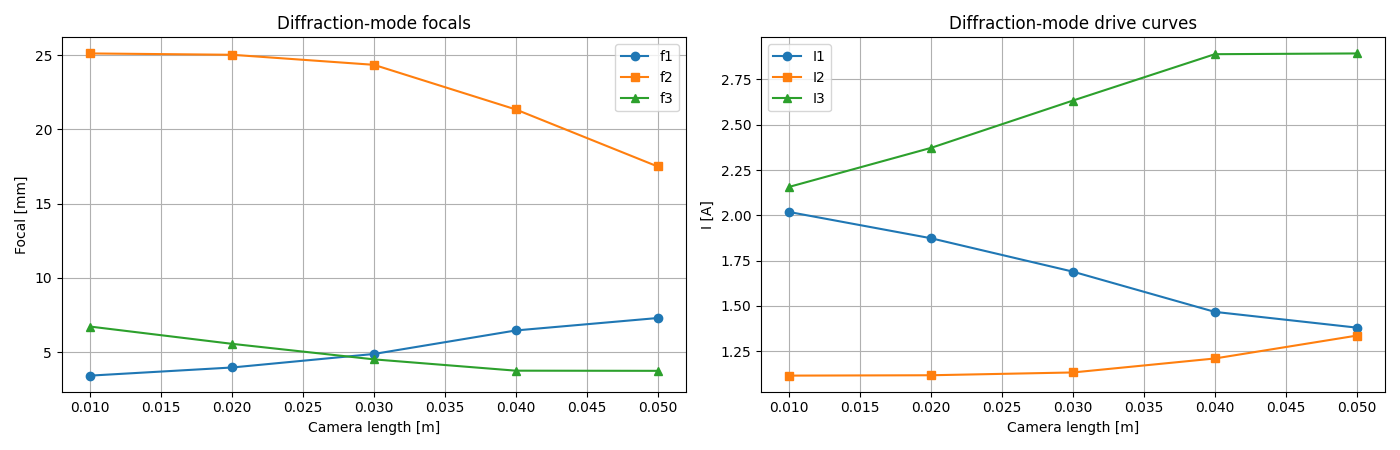

Rotation cancellation residual (imaging, max): 1126.63 AT
Rotation cancellation residual (diffraction, max): 1126.63 AT
ObjPost: f=2.2258 mm, I=-2.497986 A (fixed)
PL1:     f=3.2178 mm, I=-3.116334 A (fixed)
Updated design-curve mode tables in: microscope.toml
  spots: 8  mag points: 5  diff points: 5


In [ ]:

# --- Four curve plots (condenser + imaging mode) ---
spot_idx = np.array([r['spot_index'] for r in results_cond], dtype=float)
f_cl1_mm = np.array([r['f_CL1'] for r in results_cond], dtype=float) * 1e3
f_cl3_mm = np.array([r['f_CL3'] for r in results_cond], dtype=float) * 1e3
i_cl1_a = np.array([r['I_A_CL1'] for r in results_cond], dtype=float)
i_cl3_a = np.array([r['I_A_CL3'] for r in results_cond], dtype=float)

x_sys = np.array(target_system_mags, dtype=float)
f1_mag_mm = np.array([r['f1_m'] for r in mag_results], dtype=float) * 1e3
f2_mag_mm = np.array([r['f2_m'] for r in mag_results], dtype=float) * 1e3
f3_mag_mm = np.array([r['f3_m'] for r in mag_results], dtype=float) * 1e3
i1_mag_a = np.array([r['I1_A'] for r in mag_results], dtype=float)
i2_mag_a = np.array([r['I2_A'] for r in mag_results], dtype=float)
i3_mag_a = np.array([r['I3_A'] for r in mag_results], dtype=float)

fig, axs = plt.subplots(2, 2, figsize=(14, 9))

axs[0, 0].plot(spot_idx, f_cl1_mm, 'o-', label='f_CL1')
axs[0, 0].plot(spot_idx, f_cl3_mm, 's-', label='f_CL3')
axs[0, 0].set(title='Condenser focals', xlabel='Spot index', ylabel='Focal [mm]')
axs[0, 0].legend()

axs[0, 1].plot(spot_idx, i_cl1_a, 'o-', label='CL1')
axs[0, 1].plot(spot_idx, i_cl3_a, 's-', label='CL3')
axs[0, 1].set(title='Condenser drive curves', xlabel='Spot index', ylabel='I [A]')
axs[0, 1].legend()

axs[1, 0].semilogx(x_sys, f1_mag_mm, 'o-', label='f1')
axs[1, 0].semilogx(x_sys, f2_mag_mm, 's-', label='f2')
axs[1, 0].semilogx(x_sys, f3_mag_mm, '^-', label='f3')
axs[1, 0].set(title='Imaging-mode focals', xlabel='System magnification', ylabel='Focal [mm]')
axs[1, 0].legend()

axs[1, 1].semilogx(x_sys, i1_mag_a, 'o-', label='I1')
axs[1, 1].semilogx(x_sys, i2_mag_a, 's-', label='I2')
axs[1, 1].semilogx(x_sys, i3_mag_a, '^-', label='I3')
axs[1, 1].set(title='Imaging-mode drive curves', xlabel='System magnification', ylabel='I [A]')
axs[1, 1].legend()

fig.tight_layout()
plt.show()

# --- Diffraction mode plots ---
x_cam_m = np.array([r['camera_length_target_m'] for r in diff_results], dtype=float)
f1_diff_mm = np.array([r['f1_m'] for r in diff_results], dtype=float) * 1e3
f2_diff_mm = np.array([r['f2_m'] for r in diff_results], dtype=float) * 1e3
f3_diff_mm = np.array([r['f3_m'] for r in diff_results], dtype=float) * 1e3
i1_diff_a = np.array([r['I1_A'] for r in diff_results], dtype=float)
i2_diff_a = np.array([r['I2_A'] for r in diff_results], dtype=float)
i3_diff_a = np.array([r['I3_A'] for r in diff_results], dtype=float)

fig_diff, axs_diff = plt.subplots(1, 2, figsize=(14, 4.5))
axs_diff[0].plot(x_cam_m, f1_diff_mm, 'o-', label='f1')
axs_diff[0].plot(x_cam_m, f2_diff_mm, 's-', label='f2')
axs_diff[0].plot(x_cam_m, f3_diff_mm, '^-', label='f3')
axs_diff[0].set(title='Diffraction-mode focals', xlabel='Camera length [m]', ylabel='Focal [mm]')
axs_diff[0].legend()

axs_diff[1].plot(x_cam_m, i1_diff_a, 'o-', label='I1')
axs_diff[1].plot(x_cam_m, i2_diff_a, 's-', label='I2')
axs_diff[1].plot(x_cam_m, i3_diff_a, '^-', label='I3')
axs_diff[1].set(title='Diffraction-mode drive curves', xlabel='Camera length [m]', ylabel='I [A]')
axs_diff[1].legend()

fig_diff.tight_layout()
plt.show()

# --- ObjPost / PL1 currents (both fixed by optics) ---
turns_objpost = turns_all['Obj_post']
turns_pl1 = turns_all['PL1']
Gc_objpost = Gc_all['Obj_post']
Gc_pl1 = Gc_all['PL1']
comp_sign = -1.0  # oppose IL rotation sign

ni_mag_total = np.array([r['AT1'] + r['AT2'] + r['AT3'] for r in mag_results], dtype=float)
ni_diff_total = np.array([r['AT1'] + r['AT2'] + r['AT3'] for r in diff_results], dtype=float)

ni_objpost_scalar = float(np.sqrt(1.0 / (Gc_objpost * f_obj_required_m)))
ni_pl1_scalar = float(np.sqrt(1.0 / (Gc_pl1 * f_pl1_target_m)))

# ObjPost current is fixed by M_obj (objective magnification)
ni_objpost_mag = np.full(ni_mag_total.shape, comp_sign * ni_objpost_scalar, dtype=float)
ni_objpost_diff = np.full(ni_diff_total.shape, comp_sign * ni_objpost_scalar, dtype=float)
# PL1 current is fixed by projector geometry
ni_pl1_mag = np.full(ni_mag_total.shape, comp_sign * ni_pl1_scalar, dtype=float)
ni_pl1_diff = np.full(ni_diff_total.shape, comp_sign * ni_pl1_scalar, dtype=float)

i_a_objpost_mag = ni_objpost_mag / turns_objpost
i_a_objpost_diff = ni_objpost_diff / turns_objpost
i_a_pl1_mag = ni_pl1_mag / turns_pl1
i_a_pl1_diff = ni_pl1_diff / turns_pl1

f_obj_from_current = 1.0 / (Gc_objpost * (turns_objpost * i_a_objpost_mag)**2)
if not np.allclose(f_obj_from_current, f_obj_required_m, rtol=1e-6):
    raise RuntimeError(f'ObjPost current does not realize required f_obj={f_obj_required_m*1e3:.4f} mm.')

f_pl1_from_current = 1.0 / (Gc_pl1 * (turns_pl1 * i_a_pl1_mag)**2)
if not np.allclose(f_pl1_from_current, f_pl1_target_m, rtol=1e-6):
    raise RuntimeError('PL1 current does not realize target focal length.')

net_ni_mag = ni_mag_total + ni_objpost_mag + ni_pl1_mag
net_ni_diff = ni_diff_total + ni_objpost_diff + ni_pl1_diff
print(f'Rotation cancellation residual (imaging, max): {np.max(np.abs(net_ni_mag)):.2f} AT')
print(f'Rotation cancellation residual (diffraction, max): {np.max(np.abs(net_ni_diff)):.2f} AT')

print(f'ObjPost: f={f_obj_required_m*1e3:.4f} mm, I={i_a_objpost_mag[0]:.6f} A (fixed)')
print(f'PL1:     f={f_pl1_target_m*1e3:.4f} mm, I={i_a_pl1_mag[0]:.6f} A (fixed)')

# --- Write updated curves back to microscope.toml ---

def _fmt_scalar(v: float) -> str:
    return f'{float(v):.16g}'

def _replace_mode_values(text: str, section: str, rows) -> str:
    """Replace the values = [...] block under [section] using bracket-depth line scanning.
    
    This avoids regex over nested arrays, which is fragile. Instead we:
    1. Find the exact section header line.
    2. Scan forward to find the 'values = [' line.
    3. Track bracket depth to find the closing ] of the outer array.
    4. Splice in the new rows.
    """
    lines = text.splitlines(keepends=True)

    # 1. Find section header
    section_header = f'[{section}]'
    sec_idx = None
    for i, line in enumerate(lines):
        if line.strip() == section_header:
            sec_idx = i
            break
    if sec_idx is None:
        raise RuntimeError(f'Section [{section}] not found in TOML')

    # 2. Find 'values' key within this section (stop at next top-level section)
    val_start = None
    for i in range(sec_idx + 1, len(lines)):
        stripped = lines[i].strip()
        # Stop if we hit a new section header
        if stripped.startswith('[') and not stripped.startswith('[['):
            break
        if stripped.startswith('values'):
            val_start = i
            break
    if val_start is None:
        raise RuntimeError(f'No values key found under [{section}]')

    # 3. Track bracket depth from val_start to find the end of the array
    depth = 0
    val_end = None
    for i in range(val_start, len(lines)):
        for ch in lines[i]:
            if ch == '[':
                depth += 1
            elif ch == ']':
                depth -= 1
                if depth == 0:
                    val_end = i
                    break
        if val_end is not None:
            break
    if val_end is None:
        raise RuntimeError(f'Unclosed values array for [{section}]')

    # 4. Build replacement lines
    new_lines = ['values = [\n']
    for row in rows:
        new_lines.append('\t[' + ', '.join(_fmt_scalar(x) for x in row) + '],\n')
    new_lines.append(']\n')

    result_lines = lines[:val_start] + new_lines + lines[val_end + 1:]
    return ''.join(result_lines)

parallel_rows = [
    [
        float(r['spot_index']),
        float(r['I_A_CL1']),
        float(r['I_A_CL3']),
        1.0,
    ]
    for r in results_cond
]

mag_rows = [
    [
        float(m),
        1.0,
        float(i_obj),
        float(r['I1_A']),
        float(r['I2_A']),
        float(r['I3_A']),
        float(i_pl1),
    ]
    for m, r, i_obj, i_pl1 in zip(target_system_mags, mag_results, i_a_objpost_mag, i_a_pl1_mag)
]

diff_rows = [
    [
        float(Lm),
        1.0,
        float(i_obj),
        float(r['I1_A']),
        float(r['I2_A']),
        float(r['I3_A']),
        float(i_pl1),
    ]
    for Lm, r, i_obj, i_pl1 in zip(x_cam_m, diff_results, i_a_objpost_diff, i_a_pl1_diff)
]

toml_text = toml_path.read_text(encoding='utf-8')
toml_text = _replace_mode_values(toml_text, 'modes.illumination.parallel', parallel_rows)
toml_text = _replace_mode_values(toml_text, 'modes.imaging.magnification', mag_rows)
toml_text = _replace_mode_values(toml_text, 'modes.imaging.diffraction', diff_rows)
toml_path.write_text(toml_text, encoding='utf-8')

# Validate the written TOML parses cleanly
import tomllib as _tomllib
with open(toml_path, 'rb') as _f:
    _tomllib.load(_f)

print(f'Updated design-curve mode tables in: {toml_path}')
print(f'  spots: {len(parallel_rows)}  mag points: {len(mag_rows)}  diff points: {len(diff_rows)}')


In [9]:
summary_mag = [{
    'M_system': float(r['M_system']),
    'f1_m': float(r['f1_m']),
    'f2_m': float(r['f2_m']),
    'f3_m': float(r['f3_m']),
    'I1_A': float(r['I1_A']),
    'I2_A': float(r['I2_A']),
    'I3_A': float(r['I3_A']),
    'AT1': float(r['AT1']),
    'AT2': float(r['AT2']),
    'AT3': float(r['AT3']),
} for r in mag_results]

summary_diff = [{
    'camera_length_target_m': float(r['camera_length_target_m']),
    'f1_m': float(r['f1_m']),
    'f2_m': float(r['f2_m']),
    'f3_m': float(r['f3_m']),
    'I1_A': float(r['I1_A']),
    'I2_A': float(r['I2_A']),
    'I3_A': float(r['I3_A']),
    'AT1': float(r['AT1']),
    'AT2': float(r['AT2']),
    'AT3': float(r['AT3']),
} for r in diff_results]

summary_cond = [{
    'spot_index': int(r['spot_index']),
    'f_CL1': float(r['f_CL1']),
    'f_CL3': float(r['f_CL3']),
    'I_A_CL1': float(r['I_A_CL1']),
    'I_A_CL3': float(r['I_A_CL3']),
} for r in results_cond]

import pprint
pprint.pp({
    'mag_results': summary_mag,
    'diff_results': summary_diff,
    'results_cond': summary_cond,
    'theta_target': float(theta_target),
})

{'mag_results': [{'M_system': 30000.0,
                  'f1_m': 0.0034096730962762624,
                  'f2_m': 0.02512482754934289,
                  'f3_m': 0.006714393718583197,
                  'I1_A': 2.018261242566578,
                  'I2_A': 1.115253169256152,
                  'I3_A': 2.157354966894023,
                  'AT1': 6054.783727699733,
                  'AT2': 2230.506338512304,
                  'AT3': 4314.709933788045},
                 {'M_system': 50000.0,
                  'f1_m': 0.0039574196735900425,
                  'f2_m': 0.025035261343641178,
                  'f3_m': 0.005551043807041685,
                  'I1_A': 1.873387842679598,
                  'I2_A': 1.11724635422998,
                  'I3_A': 2.372671881707146,
                  'AT1': 5620.163528038794,
                  'AT2': 2234.49270845996,
                  'AT3': 4745.343763414292},
                 {'M_system': 100000.0,
                  'f1_m': 0.004868341877294482,
           